# Conhecendo o conjunto de dados

I - Importar as bibliotecas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

II - Carregar o arquivo CSV.

In [2]:
df = pd.read_csv("Melhores_filmes_e_séries_de_TVIMDb.csv")

III - Exibir as primeiras e últimas linhas.

In [3]:
df.head(10)

,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5
5,Fight Club,movie,"Crime,Drama,Thriller",2605573,1999,8.8
6,Interstellar,movie,"Adventure,Drama,Sci-Fi",2525474,2014,8.7
7,Forrest Gump,movie,"Drama,Romance",2494835,1994,8.8
8,Pulp Fiction,movie,"Crime,Drama",2433805,1994,8.8
9,The Matrix,movie,"Action,Sci-Fi",2245953,1999,8.7


In [4]:
df.tail(10)

,title,titleType,genres,numVotes,year,averageRating
9989,Swing Vote,movie,"Comedy,Drama",20185,2008,6.1
9990,Ordinary Angels,movie,"Biography,Drama",20184,2024,7.4
9991,Summer Rental,movie,Comedy,20182,1985,6.3
9992,The Jungle Book,movie,"Adventure,Family,Fantasy",20180,1994,6.1
9993,April Fool's Day,movie,"Horror,Mystery",20179,1986,6.2
9994,Blood & Gold,movie,"Action,Drama,War",20178,2023,6.5
9995,Santa Claus Is Comin' to Town,tvMovie,"Adventure,Animation,Comedy",20176,1970,7.7
9996,The Tonight Show Starring Jimmy Fallon,tvSeries,"Comedy,Music,Talk-Show",20176,2014,7.0
9997,Come Play,movie,"Drama,Horror,Mystery",20172,2020,5.8
9998,Holiday,movie,"Comedy,Romance",20171,1938,7.7


IV - Identificar o número de linhas e colunas.

In [5]:
df.shape

(9999, 6)

V - Verificar os tipos de dados de cada coluna.

In [6]:
df.dtypes

title                str
titleType            str
genres               str
numVotes           int64
year               int64
averageRating    float64
dtype: object

Alteração nos nomes das colunas e criação de um  novo dataframe que tem os nomes das colunas em português.

In [7]:
df_renomeado = df.rename(columns={
    'title':'Titulo', 
    'titleType':'Categoria', 
    'genres':'Generos', 
    'numVotes':'Numero_Votos', 
    'year':'Ano', 
    'averageRating':'Media_Avaliacao'
})

In [8]:
df_renomeado.columns

Index(['Titulo', 'Categoria', 'Generos', 'Numero_Votos', 'Ano',
       'Media_Avaliacao'],
      dtype='str')

# Qualidade dos dados

I - Verificar valores nulos.

In [9]:
print(df_renomeado.isnull().sum())

np.where(df.isnull())

Titulo             0
Categoria          0
Generos            1
Numero_Votos       0
Ano                0
Media_Avaliacao    0
dtype: int64


(array([4841]), array([2]))

II - Verificar valores duplicados.

In [10]:
print(df_renomeado.duplicated().sum())

0


III - Identificar possíveis inconsistências.

In [11]:
print(df_renomeado[df_renomeado["Numero_Votos"] < 0], "\n")
print(df_renomeado[(df_renomeado["Media_Avaliacao"] < 0) | (df_renomeado["Media_Avaliacao"] > 10)], "\n")
print(df_renomeado["Categoria"].unique(), "\n")
print(df_renomeado["Generos"].unique(), "\n")

Empty DataFrame
Columns: [Titulo, Categoria, Generos, Numero_Votos, Ano, Media_Avaliacao]
Index: [] 

Empty DataFrame
Columns: [Titulo, Categoria, Generos, Numero_Votos, Ano, Media_Avaliacao]
Index: [] 

<StringArray>
[       'movie',     'tvSeries', 'tvMiniSeries',    'tvSpecial',
      'tvMovie',        'video',    'videoGame',        'short',
      'tvShort']
Length: 9, dtype: str 

<StringArray>
[                   'Drama',       'Action,Crime,Drama',
  'Action,Adventure,Sci-Fi',   'Action,Adventure,Drama',
     'Crime,Drama,Thriller',   'Adventure,Drama,Sci-Fi',
            'Drama,Romance',              'Crime,Drama',
            'Action,Sci-Fi',  'Adventure,Drama,Fantasy',
 ...
   'Family,Fantasy,Musical',     'Comedy,Crime,History',
  'Drama,Horror,Reality-TV',    'Crime,Sci-Fi,Thriller',
    'Action,Horror,Romance',      'Comedy,Horror,Music',
             'Action,Short',  'Crime,Documentary,Sport',
 'Animation,Fantasy,Horror',    'Action,Horror,Western']
Length: 466, dtype: st

IV - Realizar a limpeza, se necessário.

In [12]:
#substituir o valor nulo por um texto
df_renomeado["Generos"] = df_renomeado["Generos"].fillna("Desconhecido")

print(df_renomeado.isnull().sum())

Titulo             0
Categoria          0
Generos            0
Numero_Votos       0
Ano                0
Media_Avaliacao    0
dtype: int64


# Estatísticas descritivas

In [13]:
print("Principais estatísticas\n", df_renomeado[["Numero_Votos", "Media_Avaliacao"]].describe(), "\n")

print("Média:")
print(f"Número de votos: {np.mean(df_renomeado["Numero_Votos"])}\n")

print(f"Mediana:")
print(f"Número de votos: {np.median(df_renomeado["Numero_Votos"])}")
print(f"Ano: {np.median(df_renomeado["Ano"])}")
print(f"Média de avaliações: {np.median(df_renomeado["Media_Avaliacao"])}\n")


Principais estatísticas
        Numero_Votos  Media_Avaliacao
count  9.999000e+03      9999.000000
mean   1.215959e+05         6.849405
std    2.002060e+05         1.046733
min    2.017100e+04         1.000000
25%    3.065550e+04         6.200000
50%    5.417300e+04         6.900000
75%    1.228770e+05         7.600000
max    3.185932e+06         9.800000 

Média:
Número de votos: 121595.92139213921

Mediana:
Número de votos: 54173.0
Ano: 2010.0
Média de avaliações: 6.9



# Visualização dos dados

- Quantidade de produções por categoria

      Categoria  Quantidade  Porcentagem
0         movie        8208    82.088209
1      tvSeries        1326    13.261326
2  tvMiniSeries         245     2.450245
3         video          86     0.860086
4       tvMovie          46     0.460046
5     videoGame          40     0.400040
6         short          35     0.350035
7     tvSpecial          11     0.110011
8       tvShort           2     0.020002 

      Categoria  Quantidade  Porcentagem
0         movie        8208    82.088209
1      tvSeries        1326    13.261326
2  tvMiniSeries         245     2.450245 

   Categoria  Quantidade  Porcentagem
3      video          86     0.860086
4    tvMovie          46     0.460046
5  videoGame          40     0.400040
6      short          35     0.350035
7  tvSpecial          11     0.110011
8    tvShort           2     0.020002 

      Categoria  Quantidade
0         movie        8208
1      tvSeries        1326
2  tvMiniSeries         245
3        Outras         220


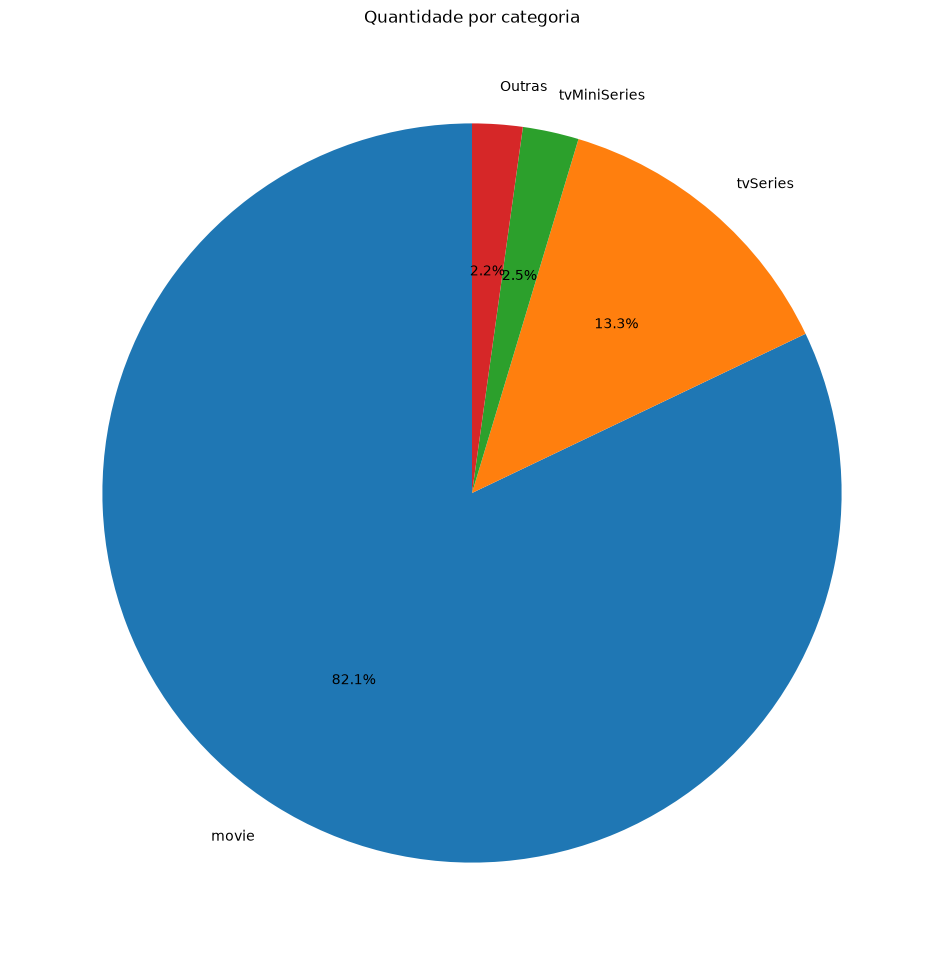

In [42]:
#Gráfico de barras(bar)
qtd_categoria = df_renomeado["Categoria"].value_counts()
qtd_categoria = qtd_categoria.reset_index()
qtd_categoria = qtd_categoria.rename(columns={'count':'Quantidade'})

qtd_categoria["Porcentagem"] = (qtd_categoria["Quantidade"] / qtd_categoria["Quantidade"].sum()) * 100

principais = qtd_categoria[qtd_categoria["Porcentagem"] >= 2].copy()
pequenos = qtd_categoria[qtd_categoria["Porcentagem"] < 2].copy()

linha_outras = pd.DataFrame({
    'Categoria': ['Outras'],
    'Quantidade': [pequenos["Quantidade"].sum()]
})
    
df_grafico = pd.concat([principais[['Categoria', 'Quantidade']], linha_outras], ignore_index=True)

print(qtd_categoria, '\n')
print(principais, '\n')
print(pequenos, '\n')
print(df_grafico)

plt.figure(figsize=(12, 12))

plt.pie(
    df_grafico["Quantidade"],
    labels= df_grafico["Categoria"],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Quantidade por categoria")
plt.show()

Neste gráfico de pizza de quantidade por categoria conseguimos visualizar o percentual de cada categoria. Há o percentual das 3 maiores categorias, e as demais categorias, que apresentaram um percentual de menos de 2%, estão agrupadas na categoria outras. Pode ser observado que há uma discrepância entre as elas, aquela que maior percentual de produção é filmes.

- Quantidade de produções por década

Ano da produção mais recente: 2026
Ano da produção mais antiga: 1902 

Ano
1900-1909       2
1910-1919       1
1920-1929      15
1930-1939      42
1940-1949      80
1950-1959     129
1960-1969     203
1970-1979     303
1980-1989     646
1990-1999    1202
2000-2009    2322
2010-2019    3274
2020-2029    1780
Name: count, dtype: int64


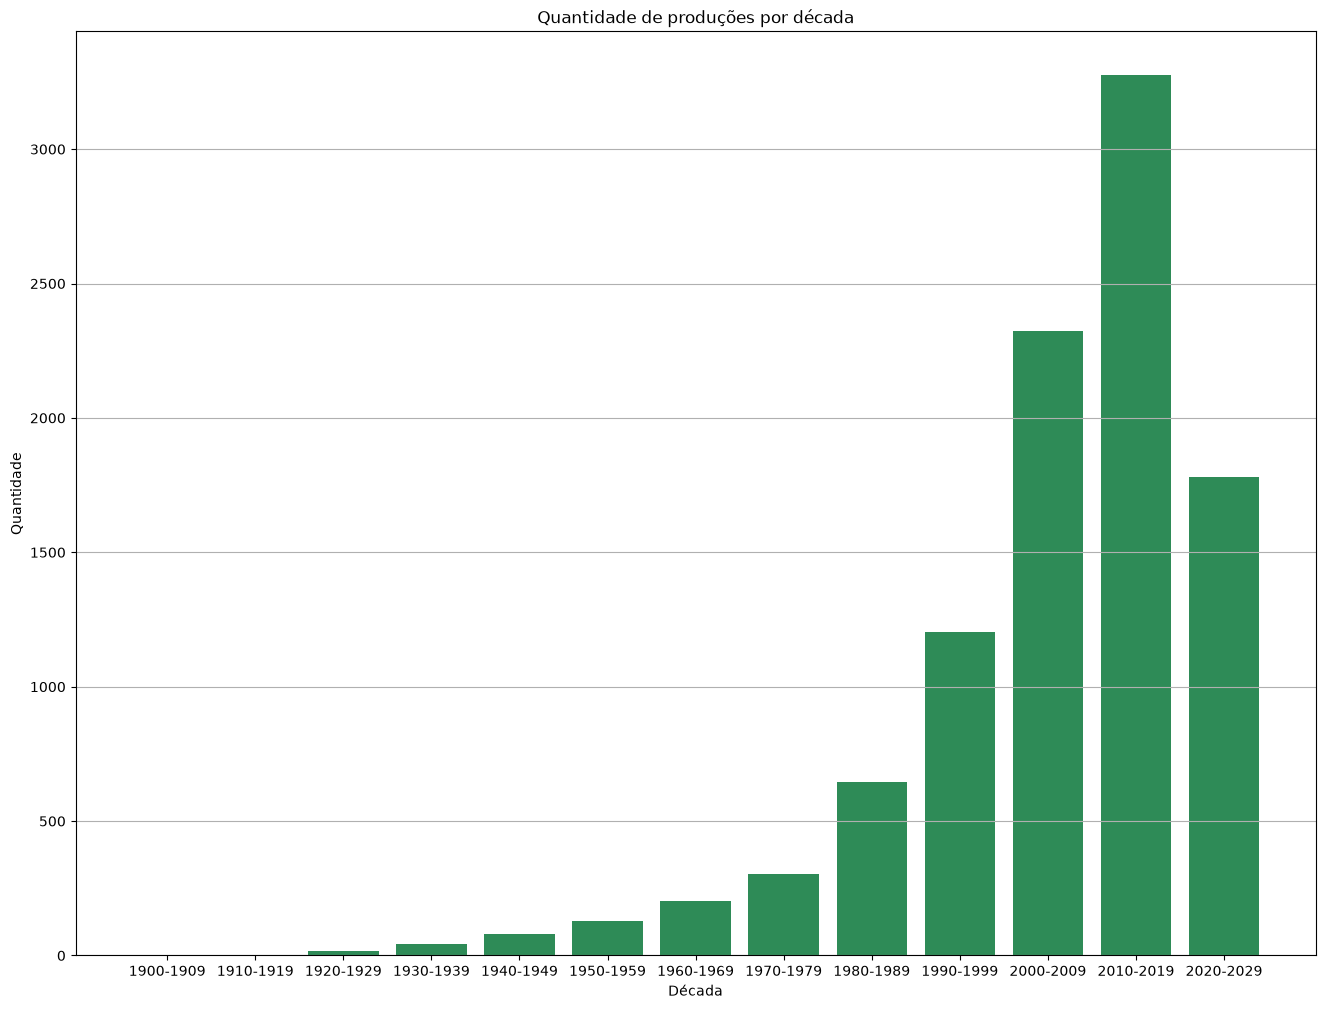

In [ ]:
#Gráfico de barras(bar)
print("Ano da produção mais recente:", df_renomeado["Ano"].max())
print("Ano da produção mais antiga:", df_renomeado["Ano"].min(), '\n')

decada = (df_renomeado["Ano"] // 10) * 10
decada_rotulo = decada.astype(str) + "-" + (decada + 9).astype(str)

qtd_por_decada = decada_rotulo.value_counts().sort_index()
print(qtd_por_decada)

plt.figure(figsize=(16, 12))
plt.bar(qtd_por_decada.index, qtd_por_decada.values, color="seagreen")
plt.title("Quantidade de produções por década")
plt.xlabel("Década")
plt.ylabel("Quantidade")
plt.grid(axis="y")
plt.show()

#rever se tem a possibilidade de criar um gráfico que mostre a quantidade de cada categoria(ou gênero) ao longo dos anos.

Ao longo das décadas percebe-se que houve um crescimento nas produções. Além disso, durante a década de 2010-2019 teve a maior qantidade de produções. Na década de 2020-2029 só há produções até o ano de 2026, mesmo assim a quantidade de produções até este ano levou a chegar em mais da metade da quantidade de produções em comparação com a década anterior. 

- Quantidade de produções por gênero

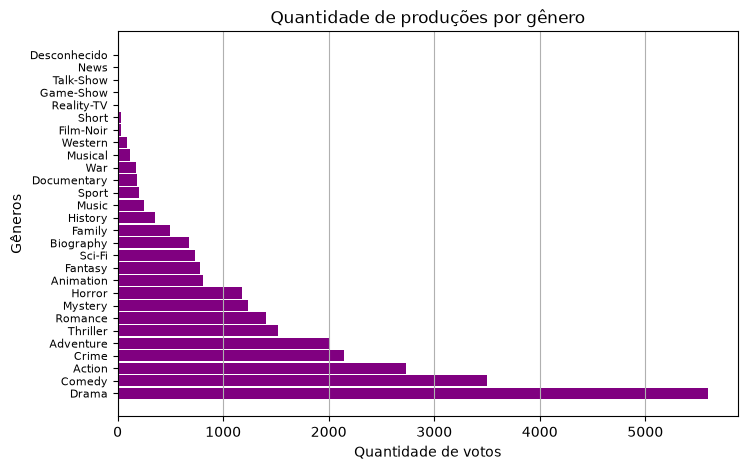

In [17]:
#Gráfico de barras horizontal(barh)
generos = df_renomeado["Generos"]
generos = generos.str.split(",")
generos = generos.explode()
generos = generos.str.strip()

qtd_generos = generos.value_counts()

plt.figure(figsize=(8, 5))
plt.barh(qtd_generos.index, qtd_generos.values, height=0.9, color="purple")
plt.xlabel("Quantidade de votos")
plt.ylabel("Gêneros")
plt.title("Quantidade de produções por gênero")
plt.tick_params(axis='y', labelsize=8)
plt.grid(axis='x')
plt.show()

Quanto a quantidade de produções por gêneros temos que drama, comédia e ação são os gêneros que mais se destacaram, com a maior quantidade sendo de drama, havendo uma discrepância enorme entre drama e as demais categorias, considerando produções do período de 1902 até 2026.

Nota-se uma discrepância entre a quantidade de votos de avaliações, devido que cada categoria teve uma quantidade de produções bem distintas entre si, e como a categoria filme é que mais teve produção, então temos também que foi a que mais teve quantidade de votos, fazendo com que a maioria das barras das demais categorias fossem quase nula, ao comparar com aquelas que tiveram pelo menos 1 milhão de votos.

- Média dos votos por categoria

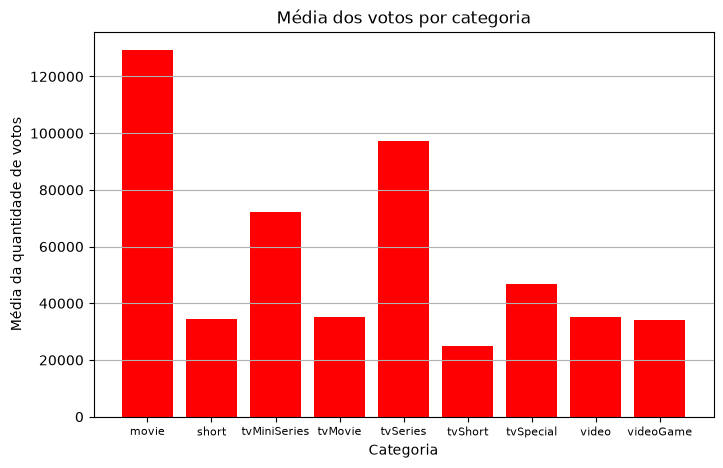

In [18]:
media_votos = df_renomeado.groupby("Categoria")["Numero_Votos"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(media_votos["Categoria"], media_votos["Numero_Votos"], color="red")
plt.xlabel("Categoria")
plt.ylabel("Média da quantidade de votos")
plt.title("Média dos votos por categoria")
plt.tick_params(axis='x', labelsize=8)
plt.grid(axis='y')
plt.show()

Quanto a análise da quantidade de votos por categoria, temos este gráfico que analisa a média da quantidade de votos de avaliações por categoria. Dentre os demais gráficos, este é o que mais mostra uma diversidade dentre os dados. Além disso, percebe-se que as categorias que apresentaram as maiores médias foram filme, série de televisão e minissérie de televisão.

- Média de avaliações

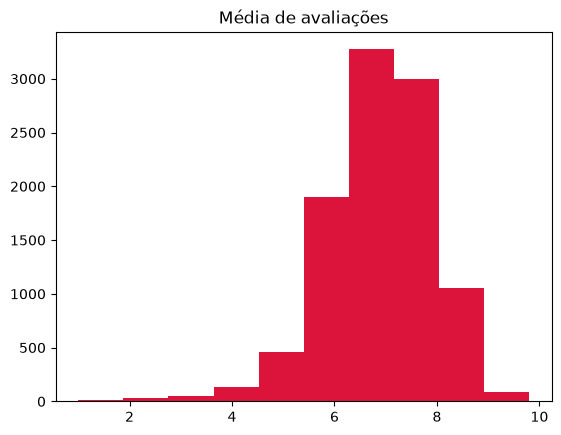

In [19]:
#Gráfico de histograma(hist)
plt.hist(df_renomeado["Media_Avaliacao"], color="crimson")
plt.title("Média de avaliações")
plt.show()

Quanto a distribuição das médias de avaliações, tem-se que há poucas avaliações baixas e também poucas avaliações de 9 à 10. Percebe-se que as médias de avaliações estão centradas no intervalo de 6 à 8, em que as maiores quantidades está entre 7 e 8.

- Médias de Avalições (Top 3 de Categorias)

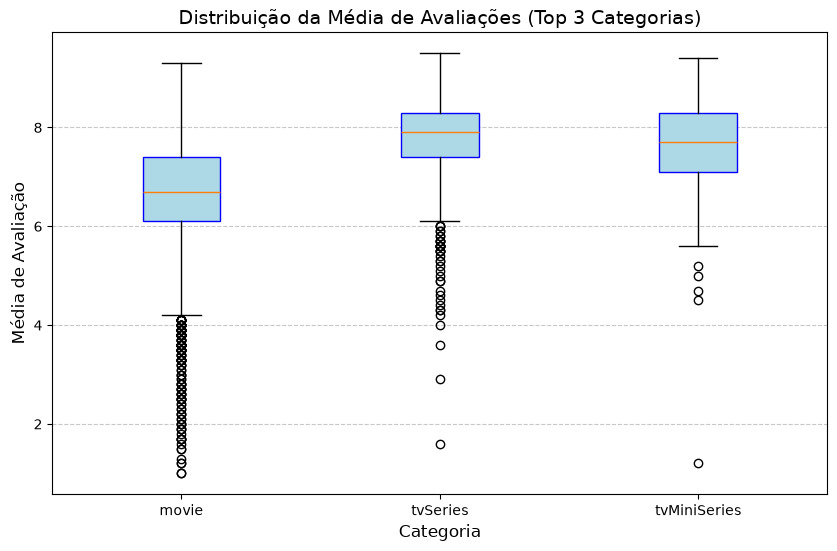

In [29]:
#Boxplot
top3_categorias = df_renomeado['Categoria'].value_counts().head(3).index
dados = [
    df_renomeado[df_renomeado['Categoria'] == cat]['Media_Avaliacao']
    for cat in top3_categorias
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    dados, 
    tick_labels=top3_categorias, 
    patch_artist=True, 
    boxprops=dict(facecolor='lightblue', color='blue')
)

plt.title("Distribuição da Média de Avaliações (Top 3 Categorias)", fontsize=14)
plt.xlabel("Categoria", fontsize=12)
plt.ylabel("Média de Avaliação", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A partir dos boxplots, observa-se que as categorias séries de televisão e minisséries de televisão apresentam as maiores medianas de avaliação (ambas próximas a 8,0), superando a categoria filme (com mediana próxima a 6,8). A categoria minisséries de televisão destaca-se por uma distribuição mais simétrica e homogênea, apresentando a menor quantidade de outliers. Em contrapartida, filmes e séries de televisão concentram um volume significativamente maior de outliers na faixa inferior de notas.

- Média de avaliações por ano

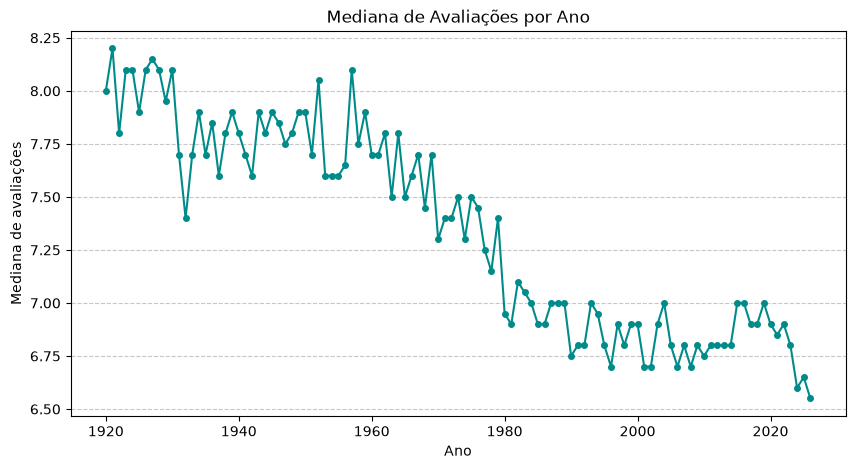

In [40]:
#Gráfico de linhas(plot)
mediana_por_ano = (
    df_renomeado.groupby("Ano")["Media_Avaliacao"]
    .median()
    .reset_index()
    .sort_values("Ano")
)

mediana_por_ano = mediana_por_ano[mediana_por_ano['Ano'] >= 1920]

plt.figure(figsize=(10, 5))
plt.plot(mediana_por_ano["Ano"], mediana_por_ano["Media_Avaliacao"], color="darkcyan", marker='o', markersize=4, linewidth=1.5)

plt.xlabel("Ano")
plt.ylabel("Mediana de avaliações")
plt.title("Mediana de Avaliações por Ano")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.show()

Analisando a mediana das avaliações por ano a partir de 1920, observam-se três comportamentos distintos: entre 1920 e 1960, as notas permanecem em um patamar alto, oscilando predominantemente na faixa de 7.5 a 8.2 (com uma única queda pontual próxima a 7.4 na década de 1930). A partir de 1960 até 1980, ocorre uma tendência contínua de declínio, onde a mediana cai de aproximadamente 7.8 para o patamar de 7.0. De 1980 em diante, o indicador se estabiliza em uma faixa mais baixa, concentrando-se de 6.7 à 7.0, apresentando uma ligeira queda adicional nos últimos anos.

- Quantidade de votos por ano ou década

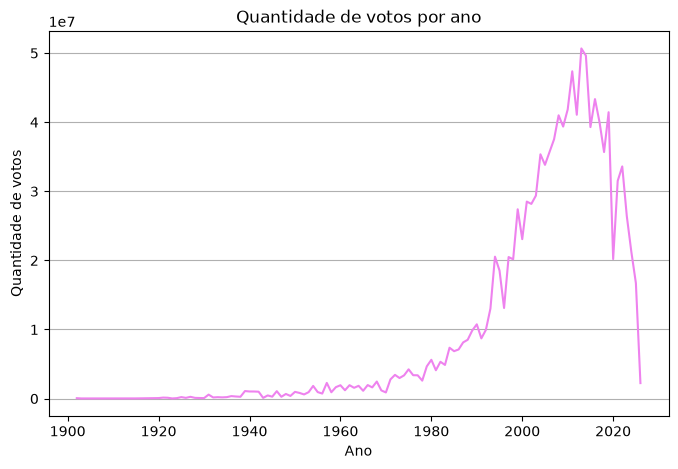

In [22]:
#gráfico de linhas(plot)
votos_ano = df_renomeado.groupby("Ano")["Numero_Votos"].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(votos_ano["Ano"], votos_ano["Numero_Votos"], color="violet")
plt.xlabel("Ano")
plt.ylabel("Quantidade de votos")
plt.title("Quantidade de votos por ano")
plt.grid(axis='y')
plt.show()

Por meio deste gráfico de linhas nota-se que o gráfico primeiro tem um comportamento constante de 1900 à 1920, depois tem um crescimento na quantidade de votos conforme os anos. Apenas durante o período de 2015 a 2026 houve uma baixa na quantidade de votos. O pico máximo do gráfico se deu próximo de 2015.

- Relação entre número de votos e média de avaliações 

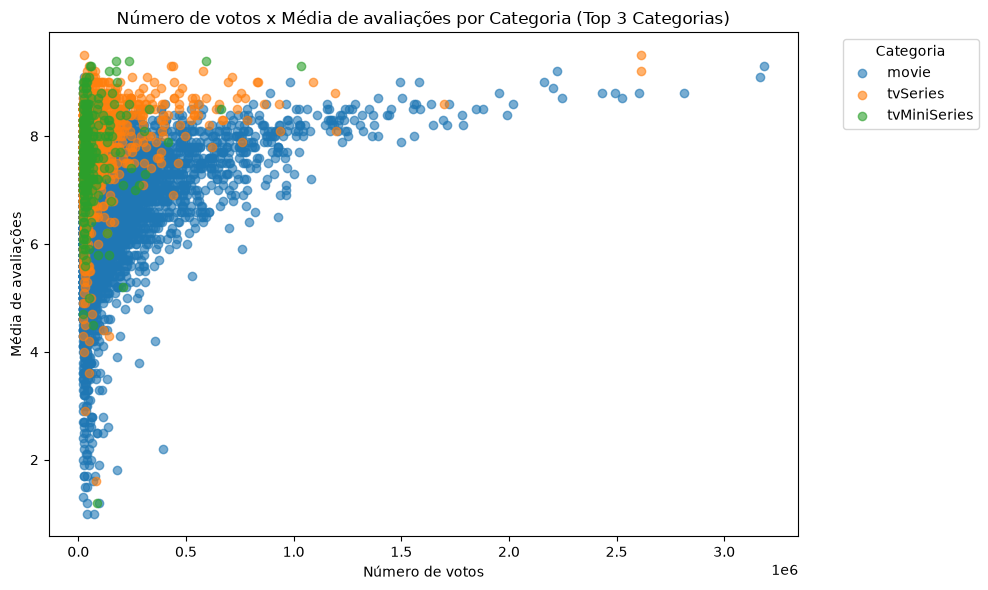

In [50]:
#Gráfico de dispersão(scatter)
top3_categorias = df_renomeado['Categoria'].value_counts().nlargest(3).index
df_top3 = df_renomeado[df_renomeado['Categoria'].isin(top3_categorias)]

plt.figure(figsize=(10,6))

for categoria in top3_categorias:
    subset = df_top3[df_top3['Categoria'] == categoria]
    plt.scatter(subset['Numero_Votos'], subset['Media_Avaliacao'], label=categoria, alpha=0.6)


plt.title("Número de votos x Média de avaliações por Categoria (Top 3 Categorias)")
plt.xlabel("Número de votos")
plt.ylabel("Média de avaliações")

plt.legend(title="Categoria", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

A categoria de filmes apresenta a maior variabilidade, cobrindo tanto as notas mais baixas quanto os maiores volumes de votação. A grande concentração de pontos de todas as categorias está na faixa de até 200 mil votos ($0.2 \times 10^6$). As séries de televisão atingiram a maior nota pontual do gráfico (próxima a 9.5), enquanto a categoria de minisséries se concentra quase totalmente em volumes menores de votos (até 200 mil). Além disso, observa-se que os filmes com volumes muito altos de engajamento (acima de 1 milhão de votos) mantêm médias de avaliação consistentemente altas, predominantemente entre 7.5 e 9.0.

# Conclusão

Na análise de produções por categoria conclui-se que a categoria que há mais produção é a de filmes com 8208 produções seguido de séries de televisão com 1326 e minisséries de televisão com 245. O percentual da produção de filmes é de 82.1%, séries de televisão tem 13.3%, minisséries de televisão tem 2.5% e outras categorias tem 2.2%.

A cerca da análise da quantidade de produções por década é importante destacar que conforme o passar das décadas a quantidade de produções aumenta, pode-se dizer que há um crescimento exponencial, até o período de 2020.

Quanto a análise de produções por gêneros temos que drama foi o gênero que mais se destacou com mais de 5000 produções, seguido por comédia com mais de 3000 e ação com mais de 2000.

Com relação a média dos votos por categoria, temos que as categorias de filme, séries de televisão e minisséries de televisão foram as que apresentaram as maiores médias dos votos. Enquanto as demais categorias tiveram uma média próximas umas das outras, na faixa de 20000 à 50000 votos.

Analisando a distribuição das médias de avaliações conclui-se que há poucas avaliações baixa, no intervalo de 1 à 4, e também poucas avaliações de 9 à 10. Além disso as médias de avaliações estão centradas entre 6 e 8 e as maiores quantidade de médias está entre 7 e 8.

Com relação à distribuição das médias de avaliações do top 3 de categorias(filmes, séries e minisséries) tem-se que as categorias séries de televisão e minisséries de televisão apresentam as maiores medianas de avaliação (ambas próximas a 8,0), superando a categoria filme (com mediana próxima a 6,8). A categoria minisséries de televisão destaca-se por uma distribuição mais simétrica e homogênea, apresentando a menor quantidade de outliers. Em contrapartida, filmes e séries de televisão concentram um volume significativamente maior de outliers na faixa inferior de notas.

Analisando a mediana das avaliações por ano a partir de 1920, observam-se três comportamentos distintos: entre 1920 e 1960, as notas permanecem em um patamar alto, oscilando predominantemente na faixa de 7.5 a 8.2 (com uma única queda pontual próxima a 7.4 na década de 1930). A partir de 1960 até 1980, ocorre uma tendência contínua de declínio, onde a mediana cai de aproximadamente 7.8 para o patamar de 7.0. De 1980 em diante, o indicador se estabiliza em uma faixa mais baixa, concentrando-se de 6.7 à 7.0, apresentando uma ligeira queda adicional nos últimos anos.

Em quantidade de votos por ano, de 1900 à 1920, temos um comportamento constante, após esse período começa a crescer a quantidade de votos.  Próximo de 2015 apresentou seu pico máximo e a partir daí ocorreu uma baixa na quantidade de votos.

Por fim, na análise do número de votos por média de avaliações com o top 3 de categorias(filmes, séries e minisséries), a categoria de filmes apresenta a maior variabilidade, cobrindo tanto as notas mais baixas quanto os maiores volumes de votação. A grande concentração de pontos de todas as categorias está na faixa de até 200 mil votos ($0.2 \times 10^6$). As séries de televisão atingiram a maior nota pontual do gráfico (próxima a 9.5), enquanto a categoria de minisséries se concentra quase totalmente em volumes menores de votos (até 200 mil). Além disso, observa-se que os filmes com volumes muito altos de engajamento (acima de 1 milhão de votos) mantêm médias de avaliação consistentemente altas, predominantemente entre 7.5 e 9.0.